# M2: LSTM

## Imports & Config

In [9]:
import os, random
import numpy as np
import tensorflow as tf
from keras.layers import Input, Embedding, LSTM, Dense, Dropout
from keras.models import Model
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE= 0.0001
MAX_LEN = 200
VOCAB_SIZE = 10000
EMBED_DIM = 128
DROPOUT_RATE = 0.3

PROCESSED_DIR = '../data/processed'
SPLITS_DIR = '../data/splits'
SAVED_MODELS_DIR = '../saved_models'


## Load Data

In [10]:
X_text = np.load(os.path.join(PROCESSED_DIR, 'X_text.npy'))
y_sentiment = np.load(os.path.join(PROCESSED_DIR, 'y_sentiment.npy'))

idx_train = np.load(os.path.join(SPLITS_DIR, 'idx_train.npy'))
idx_val = np.load(os.path.join(SPLITS_DIR, 'idx_val.npy'))
idx_test = np.load(os.path.join(SPLITS_DIR, 'idx_test.npy'))


## Data Preparation

In [11]:
X_train = X_text[idx_train]
X_val = X_text[idx_val]
X_test = X_text[idx_test]


## Label Creation

In [12]:
y_train = y_sentiment[idx_train].astype(np.int32)
y_val = y_sentiment[idx_val].astype(np.int32)
y_test = y_sentiment[idx_test].astype(np.int32)


## Train/Val/Test Split

In [13]:
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")


Train: 10500, Val: 2250, Test: 2250


## Build Model
**M2 LSTM: Why LSTM over Transformer/BERT?**
- Chosen: Stacked **LSTM** with learned word embeddings
- **GRU**: GRU is assigned to M3 for fake detection. LSTM was chosen for sentiment because its separate forget/input/output gates give finer control over long-range dependencies in longer Steam reviews.
- **BERT / Transformers**: BERT would likely achieve higher accuracy but requires GPU with 8GB+ VRAM and significantly longer training. For a course project, LSTM demonstrates sequence modeling concepts clearly. BERT is listed as a potential M5 enhancement.
- **Bag-of-Words + MLP**: BoW loses word order, which matters for sentiment (e.g. \'not good\' vs \'good\'). LSTM preserves sequential context.
- **DL concepts shown**: Sequence modeling, recurrent connections, vanishing gradient solution (gates), word embeddings


In [14]:
inputs = Input(shape=(MAX_LEN,))
x = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True)(inputs)
x = LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
x = LSTM(64)(x)
extractor_output = Dense(64, activation='relu', name='extractor_output')(x)
x = Dropout(DROPOUT_RATE)(extractor_output)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 200)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 200, 128)  │    131,584 │ embedding_1[0][0… │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 64)        │     49,408 │ lstm_2[0][0],     │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extractor_output    │ (None, 64)        │      4,160 │ lstm_3[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ extractor_output… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        130 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,465,282 (5.59 MB)

 Trainable params: 1,465,282 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [15]:
import keras
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


## Train

In [16]:
from sklearn.utils.class_weight import compute_class_weight
cw_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw = {0: cw_array[0], 1: cw_array[1]}

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(os.path.join(SAVED_MODELS_DIR, 'M2_best.keras'), save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=cw,
    callbacks=callbacks
)

Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 86s 495ms/step - accuracy: 0.4532 - loss: 0.6874 - val_accuracy: 0.6329 - val_loss: 0.6846
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 77s 468ms/step - accuracy: 0.7799 - loss: 0.5351 - val_accuracy: 0.8280 - val_loss: 0.4377
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 77s 464ms/step - accuracy: 0.8460 - loss: 0.4039 - val_accuracy: 0.8329 - val_loss: 0.4074
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 80s 485ms/step - accuracy: 0.8777 - loss: 0.3310 - val_accuracy: 0.8640 - val_loss: 0.3560
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 79s 479ms/step - accuracy: 0.8895 - loss: 0.2843 - val_accuracy: 0.8529 - val_loss: 0.3731
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 81s 490ms/step - accuracy: 0.9038 - loss: 0.2535 - val_accuracy: 0.8609 - val_loss: 0.3688
Epoch 7/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 81s 492ms/step - accuracy: 0.9110 - loss: 0.2369 - val_accuracy: 0.8640 - val_loss: 0.3658
Epoch 8/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 79s 477ms/step - accuracy: 0.9183 - loss: 0

## Training Curves

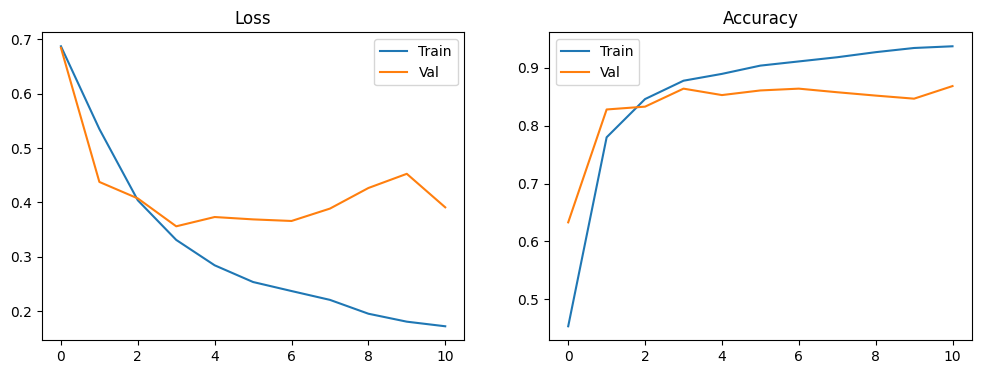

In [17]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()


## Evaluate on Test Set

In [18]:
model.evaluate(X_test, y_test)
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test

print(classification_report(y_true, y_pred))


71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8569 - loss: 0.3824
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step
              precision    recall  f1-score   support

           0       0.44      0.68      0.53       272
           1       0.95      0.88      0.92      1978

    accuracy                           0.86      2250
   macro avg       0.70      0.78      0.72      2250
weighted avg       0.89      0.86      0.87      2250



## Confusion Matrix

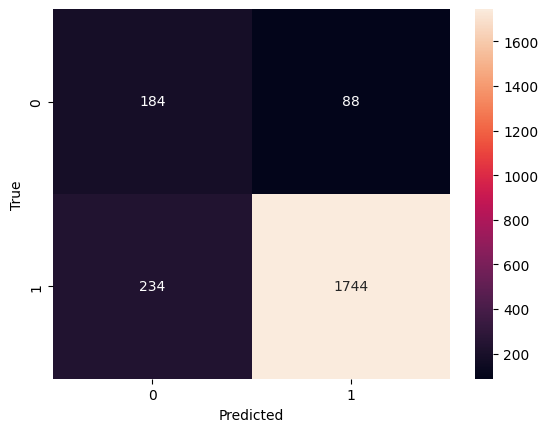

In [19]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## Error Analysis
- Common Failure Pattern: Sarcastic or ironic positive reviews predicted as negative (e.g. "Yeah sure, totally worth 200 hours of my life").
- Likely Cause: LSTM treats sarcasm as genuine negative sentiment; no sarcasm-specific training signal in the data.
- Potential Fix: Add sarcasm keyword features or augment training data with labelled sarcastic reviews.


In [20]:
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

label_names = ["Negative", "Positive"]

sample_errors = wrong_idx[:5]
for i in sample_errors:
    print(f"\n--- Sample {i} ---")
    print(f"True label: {label_names[y_true[i]]}")
    print(f"Predicted label: {label_names[y_pred[i]]}")
    print(f"Confidence: {y_pred_proba[i][y_pred[i]]*100:.1f}%")

for i, cls in enumerate(label_names[:min(len(label_names), cm.shape[0])]):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    total = cm[i, :].sum()
    if total > 0:
        print(f"{cls}: FP={fp}, FN={fn}, FNR={fn/total*100:.1f}% (missed), FPR={fp/max(1, (cm.sum()-total))*100:.1f}% (false alarms)")


Total misclassified: 322 / 2250 (14.3%)

--- Sample 30 ---
True label: Positive
Predicted label: Negative
Confidence: 88.7%

--- Sample 32 ---
True label: Positive
Predicted label: Negative
Confidence: 55.1%

--- Sample 38 ---
True label: Positive
Predicted label: Negative
Confidence: 71.5%

--- Sample 40 ---
True label: Negative
Predicted label: Positive
Confidence: 61.9%

--- Sample 41 ---
True label: Positive
Predicted label: Negative
Confidence: 57.8%
Negative: FP=234, FN=88, FNR=32.4% (missed), FPR=11.8% (false alarms)
Positive: FP=88, FN=234, FNR=11.8% (missed), FPR=32.4% (false alarms)


## Save Extractor

In [21]:
extractor = Model(inputs=model.input, outputs=model.get_layer('extractor_output').output)
extractor.save(os.path.join(SAVED_MODELS_DIR, 'M2_extractor.keras'))
